# Chapter 18: F vs B shipping capstone

The simulator runs in `generate.py` and saves to `data/ship_decisions.csv`. This notebook reads that file and lets the reader explore the cost regimes.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from expkit.plot.style import apply_style, PALETTE
apply_style()

csv = Path('chapters/18-frequentist-vs-bayesian-shipping/data/ship_decisions.csv')
if not csv.exists():
    csv = Path('data/ship_decisions.csv')
df = pd.read_csv(csv)
print(f'loaded {len(df)} simulated experiments')

def wilson_ci(k, n, z=1.96):
    """Wilson score interval for a binomial proportion. Returns (lo, hi)."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z * z / n
    center = (p + z * z / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denom
    return (max(0.0, center - half), min(1.0, center + half))

## Loop A: ship rate by true effect

In [ ]:
MMU = 0.005
bins = np.linspace(df['true_diff'].min(), df['true_diff'].max(), 16)
df['bin'] = pd.cut(df['true_diff'], bins=bins, include_lowest=True)

# Per-bin counts and Wilson 95% CIs for both ship rates. Each per-bin rate is
# itself a binomial estimate, so the lines above are point estimates; the bands
# show how much of the F-vs-B gap is real signal and how much is bin noise.
grouped = df.groupby('bin', observed=True)
counts = grouped.size()
f_k = grouped['f_ship'].sum()
b_k = grouped['b_ship'].sum()
centers = np.array([(b.left + b.right) / 2 for b in counts.index])
f_rate = (f_k / counts).values
b_rate = (b_k / counts).values
f_ci = np.array([wilson_ci(int(k), int(n)) for k, n in zip(f_k.values, counts.values)])
b_ci = np.array([wilson_ci(int(k), int(n)) for k, n in zip(b_k.values, counts.values)])

fig, ax = plt.subplots()
ax.plot(centers, f_rate, color=PALETTE['frequentist'], marker='o', label='frequentist')
ax.fill_between(centers, f_ci[:, 0], f_ci[:, 1], color=PALETTE['frequentist'], alpha=0.15, label='F Wilson 95% CI')
ax.plot(centers, b_rate, color=PALETTE['bayesian'], marker='s', label='Bayesian (MMU=0.005)')
ax.fill_between(centers, b_ci[:, 0], b_ci[:, 1], color=PALETTE['bayesian'], alpha=0.15, label='B Wilson 95% CI')
ax.axvline(0, color=PALETTE['muted'], linestyle='--', linewidth=1, label='no effect')
ax.axvline(MMU, color=PALETTE['highlight'], linestyle=':', linewidth=1, label='MMU')
ax.set_xlabel('true effect'); ax.set_ylabel('ship rate'); ax.legend(fontsize=8); plt.show()

# Matched-rule comparison ("lens-only"): if the simulator was rerun after the
# generate.py update, df has an `f_ship_matched` column with frequentist using
# point estimate > MMU. Plot it next to the in-the-wild rule so the reader can
# read off how much of the gap is the meaningfulness gate vs the lens.
if 'f_ship_matched' in df.columns:
    fm_k = grouped['f_ship_matched'].sum()
    fm_rate = (fm_k / counts).values
    fm_ci = np.array([wilson_ci(int(k), int(n)) for k, n in zip(fm_k.values, counts.values)])
    fig, ax = plt.subplots()
    ax.plot(centers, fm_rate, color=PALETTE['frequentist'], marker='o', label='frequentist matched (estimate > MMU)')
    ax.fill_between(centers, fm_ci[:, 0], fm_ci[:, 1], color=PALETTE['frequentist'], alpha=0.15)
    ax.plot(centers, b_rate, color=PALETTE['bayesian'], marker='s', label='Bayesian (MMU=0.005)')
    ax.fill_between(centers, b_ci[:, 0], b_ci[:, 1], color=PALETTE['bayesian'], alpha=0.15)
    ax.axvline(0, color=PALETTE['muted'], linestyle='--', linewidth=1)
    ax.axvline(MMU, color=PALETTE['highlight'], linestyle=':', linewidth=1, label='MMU')
    ax.set_title('Lens-only comparison (both rules carry an MMU gate)')
    ax.set_xlabel('true effect'); ax.set_ylabel('ship rate'); ax.legend(fontsize=8); plt.show()
else:
    print("note: re-run generate.py to populate `f_ship_matched` for the lens-only panel.")

## Loop B: confusion matrix

In [3]:
cm = df.groupby(['f_ship', 'b_ship']).size().unstack(fill_value=0)
cm = cm.reindex(index=[False, True], columns=[False, True], fill_value=0)
print('             B no-ship   B ship')
print(f'F no-ship      {cm.loc[False, False]:>6}     {cm.loc[False, True]:>6}')
print(f'F ship         {cm.loc[True, False]:>6}     {cm.loc[True, True]:>6}')
print()
agree = cm.loc[False, False] + cm.loc[True, True]
print(f'lenses agree on {agree}/{len(df)} = {100*agree/len(df):.1f}% of decisions')

             B no-ship   B ship
F no-ship        1855          0
F ship             29        116

lenses agree on 1971/2000 = 98.5% of decisions


## Loop C: cost regimes

Tune (FP cost, miss cost) and watch which lens has lower expected cost. Set MMU to whatever your stakeholders consider 'meaningful'.

In [ ]:
def expected_cost(df, c_fp, c_miss, mmu=0.005):
    """Constant-per-decision cost: every FP ship costs c_fp, every miss costs c_miss."""
    f_fp = ((df['f_ship'] == True) & (df['true_diff'] <= 0)).mean()
    f_miss = ((df['f_ship'] == False) & (df['true_diff'] > mmu)).mean()
    b_fp = ((df['b_ship'] == True) & (df['true_diff'] <= 0)).mean()
    b_miss = ((df['b_ship'] == False) & (df['true_diff'] > mmu)).mean()
    # Each rate is binomial(n=len(df)), so SE on each rate is roughly sqrt(p(1-p)/n).
    # For p ~ 0.05 and n=2000 that's ~0.005; for p ~ 0.1 it's ~0.007. Differences
    # in cost smaller than (c_fp + c_miss) * 0.01 should be read as noise.
    return c_fp * f_fp + c_miss * f_miss, c_fp * b_fp + c_miss * b_miss

print('Constant-per-decision cost (each FP ship and each miss weighted equally):')
for c_fp, c_miss in [(1.0, 1.0), (1.0, 5.0), (1.0, 10.0), (5.0, 1.0)]:
    f_cost, b_cost = expected_cost(df, c_fp, c_miss)
    winner = 'F' if f_cost < b_cost else 'B' if b_cost < f_cost else 'tie'
    print(f'C_fp={c_fp:>4}, C_miss={c_miss:>4}:  F cost={f_cost:.3f},  B cost={b_cost:.3f}  -> winner: {winner}')

# Effect-weighted variant: a missed +2pp win is worth ~10x a missed +0.2pp win,
# and shipping a +0pp change costs little. Penalize each false-positive ship by
# how negative the truth was, and each miss by how far past MMU the truth was.
def effect_weighted_cost(df, c_fp, c_miss, mmu=0.005):
    fp_loss_f = np.where(df['f_ship'] & (df['true_diff'] <= 0), -df['true_diff'].clip(upper=0), 0).mean()
    miss_loss_f = np.where((~df['f_ship']) & (df['true_diff'] > mmu), df['true_diff'] - mmu, 0).mean()
    fp_loss_b = np.where(df['b_ship'] & (df['true_diff'] <= 0), -df['true_diff'].clip(upper=0), 0).mean()
    miss_loss_b = np.where((~df['b_ship']) & (df['true_diff'] > mmu), df['true_diff'] - mmu, 0).mean()
    return c_fp * fp_loss_f + c_miss * miss_loss_f, c_fp * fp_loss_b + c_miss * miss_loss_b

print()
print('Effect-weighted cost (a +2pp miss is worth ~10x a +0.2pp miss):')
for c_fp, c_miss in [(1.0, 1.0), (1.0, 5.0), (1.0, 10.0), (5.0, 1.0)]:
    f_cost, b_cost = effect_weighted_cost(df, c_fp, c_miss)
    winner = 'F' if f_cost < b_cost else 'B' if b_cost < f_cost else 'tie'
    print(f'C_fp={c_fp:>4}, C_miss={c_miss:>4}:  F cost={f_cost:.5f},  B cost={b_cost:.5f}  -> winner: {winner}')

## Loop D: cost-ratio sweep

Hold C_fp = 1, sweep C_miss from 0.5 to 20. The lens with lower expected cost is the one to use under that risk profile.

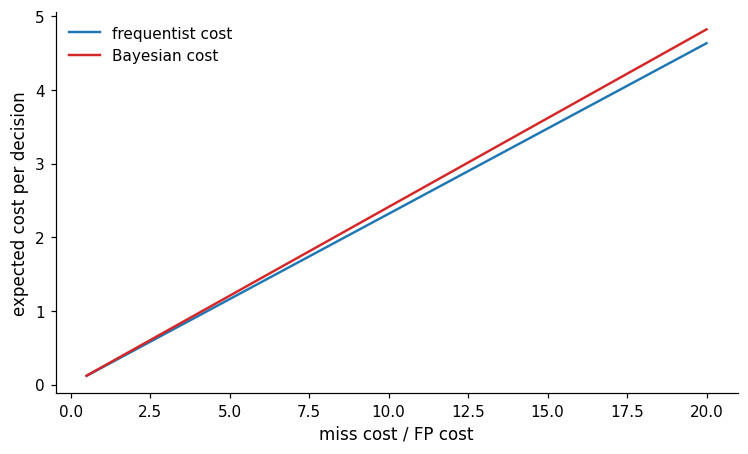

In [5]:
miss_costs = np.linspace(0.5, 20, 40)
f_costs = []; b_costs = []
for cm in miss_costs:
    f, b = expected_cost(df, 1.0, cm)
    f_costs.append(f); b_costs.append(b)
fig, ax = plt.subplots()
ax.plot(miss_costs, f_costs, color=PALETTE['frequentist'], label='frequentist cost')
ax.plot(miss_costs, b_costs, color=PALETTE['bayesian'], label='Bayesian cost')
ax.set_xlabel('miss cost / FP cost'); ax.set_ylabel('expected cost per decision'); ax.legend(); plt.show()

## Loop E: joint rule

Ship only if both lenses agree. Joint rate is more conservative than either alone.

In [ ]:
df['joint_ship'] = df['f_ship'] & df['b_ship']
print('Per-bin ship rates with Wilson 95% CIs (each rate is a binomial estimate from n trials):')
print(f'{"true_diff range":<28}  {"n":>4}  {"F (95% CI)":<22}  {"B (95% CI)":<22}  {"joint (95% CI)":<22}')
for lo, hi in [(-0.02, 0), (0, 0.005), (0.005, 0.01), (0.01, 0.02), (0.02, 0.05)]:
    sub = df[(df['true_diff'] > lo) & (df['true_diff'] <= hi)]
    n = len(sub)
    f_p = sub['f_ship'].mean(); b_p = sub['b_ship'].mean(); j_p = sub['joint_ship'].mean()
    f_lo, f_hi = wilson_ci(int(sub['f_ship'].sum()), n)
    b_lo, b_hi = wilson_ci(int(sub['b_ship'].sum()), n)
    j_lo, j_hi = wilson_ci(int(sub['joint_ship'].sum()), n)
    print(f'({lo:+.3f}, {hi:+.3f}]            {n:>4}  {f_p:.2f} [{f_lo:.2f}, {f_hi:.2f}]   {b_p:.2f} [{b_lo:.2f}, {b_hi:.2f}]   {j_p:.2f} [{j_lo:.2f}, {j_hi:.2f}]')